In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
file_name = "4) house Prediction Data Set.csv"
columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

df = pd.read_csv(file_name, sep=r'\s+', header=None, names=columns)

df['RM_NOX_Ratio'] = df['RM'] / (df['NOX'] + 1e-5)

X = df.drop(columns=['MEDV'])
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(404, 14) (102, 14) (404,) (102,)


In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Improved Model MSE: {mse:.4f}")
print(f"Improved Model R2 Score: {r2:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

Improved Model MSE: 23.6653
Improved Model R2 Score: 0.6773
Intercept: 16.4942


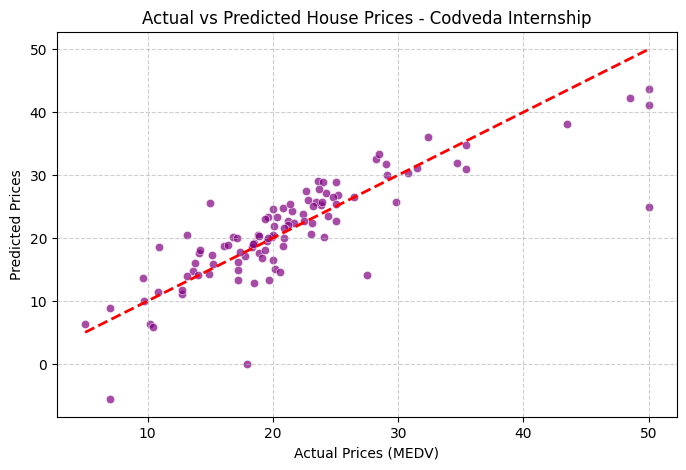

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='purple', edgecolor='w')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Prices (MEDV)")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices - Codveda Internship")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("actual_vs_predicted.png")
plt.show()

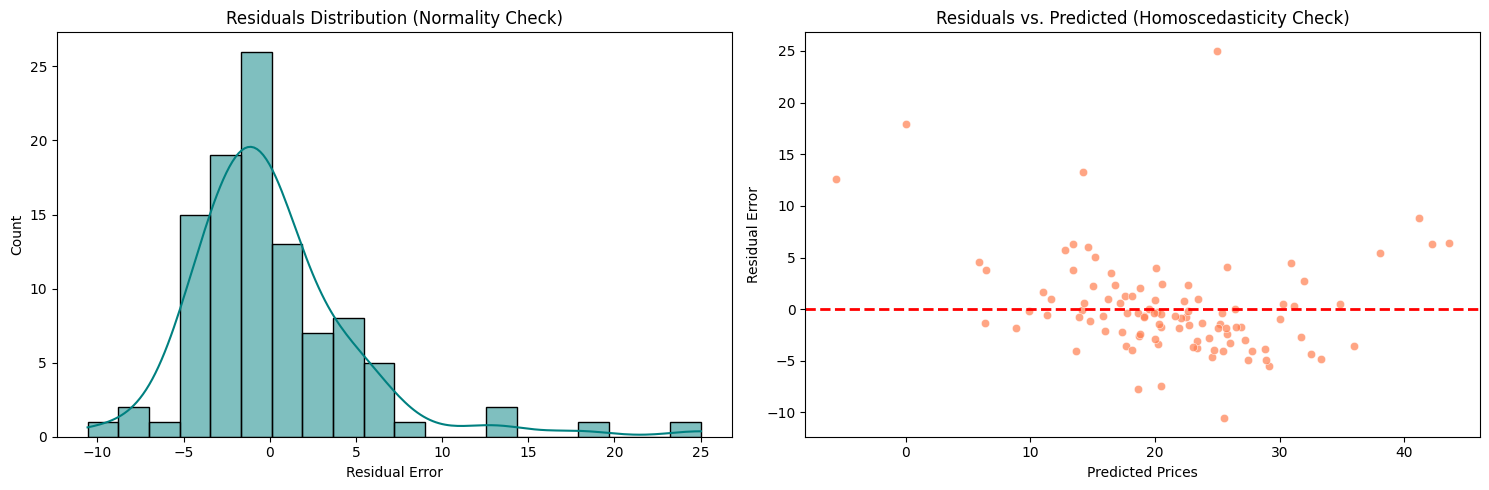

In [11]:
residuals = y_test - y_pred

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(residuals, kde=True, color='teal', ax=ax[0])
ax[0].set_title('Residuals Distribution (Normality Check)')
ax[0].set_xlabel('Residual Error')

sns.scatterplot(x=y_pred, y=residuals, alpha=0.7, color='coral', ax=ax[1])
ax[1].axhline(y=0, color='r', linestyle='--', lw=2)
ax[1].set_title('Residuals vs. Predicted (Homoscedasticity Check)')
ax[1].set_xlabel('Predicted Prices')
ax[1].set_ylabel('Residual Error')

plt.tight_layout()
plt.savefig("residuals_analysis.png")
plt.show()